In [ ]:
from matplotlib import cm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, f1_score, average_precision_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE


# 1. Load Data
df_ecommerce = pd.read_csv('../data/processed/cleaned_fraud_data.csv')
df_creditcard = pd.read_csv('../data/processed/cleaned_creditcard.csv')

# 2. Advanced Data Preparation - Ensure everything is numeric
# We identify any column that is not a number and encode it automatically
def preprocess_df(df):
    df_clean = df.copy()
    for col in df_clean.columns:
        if df_clean[col].dtype == 'object':
            le = LabelEncoder()
            df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    return df_clean

df_ecommerce = preprocess_df(df_ecommerce)

# Define features (X) and target (y)
# Drop identifiers that are not features
cols_to_drop = ['class', 'user_id', 'signup_time', 'purchase_time', 'device_id', 'ip_address']
X_ecommerce = df_ecommerce.drop(columns=[c for c in cols_to_drop if c in df_ecommerce.columns])
y_ecommerce = df_ecommerce['class']

X_creditcard = df_creditcard.drop(columns=['Class'])
y_creditcard = df_creditcard['Class']

def run_pipeline(X, y, model, model_name):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    f1_list, auc_list = [], []
    
    print(f"\n--- Evaluating {model_name} ---")
    
    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        # Apply SMOTE
        smote = SMOTE(random_state=42)
        X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
        
        model.fit(X_train_res, y_train_res)
        preds = model.predict(X_test)
        probs = model.predict_proba(X_test)[:, 1]
        
        f1_list.append(f1_score(y_test, preds))
        auc_list.append(average_precision_score(y_test, probs))
        
        # Capture the confusion matrix of the last fold
        if fold == 4:
            cm = confusion_matrix(y_test, preds)
            
    # Metrics
    print(f"Mean F1-Score: {np.mean(f1_list):.4f} (+/- {np.std(f1_list):.4f})")
    print(f"Mean AUC-PR: {np.mean(auc_list):.4f}")
    print(f"Confusion Matrix (Last Fold):\n{confusion_matrix(y_test, preds)}")

    
    # Visualize Explicit Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix (Last Fold): {model_name}")
plt.show()

    # Use the tuned models you saved earlier
run_pipeline(X_ecommerce, y_ecommerce, best_rf_ecommerce, "Tuned-RF-Ecommerce")
run_pipeline(X_creditcard, y_creditcard, best_rf_creditcard, "Tuned-RF-CreditCard")



--- Evaluating LogReg-Ecommerce ---
Mean F1-Score: 0.2787 (+/- 0.0027)
Mean AUC-PR: 0.5766
Confusion Matrix (Last Fold):
[[18122  9270]
 [  846  1984]]

--- Evaluating RF-Ecommerce ---
Mean F1-Score: 0.6194 (+/- 0.0071)
Mean AUC-PR: 0.6855
Confusion Matrix (Last Fold):
[[26306  1086]
 [ 1067  1763]]

--- Evaluating LogReg-CreditCard ---
Mean F1-Score: 0.1045 (+/- 0.0026)
Mean AUC-PR: 0.7165
Confusion Matrix (Last Fold):
[[55157  1493]
 [    7    88]]

--- Evaluating RF-CreditCard-Fast ---
Mean F1-Score: 0.3690 (+/- 0.0365)
Mean AUC-PR: 0.7093
Confusion Matrix (Last Fold):
[[56325   325]
 [   14    81]]


In [13]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
import joblib
import os

# 1. Split and Resample
X_train_ec, X_test_ec, y_train_ec, y_test_ec = train_test_split(
    X_ecommerce, y_ecommerce, test_size=0.2, stratify=y_ecommerce, random_state=42
)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_ec, y_train_ec)

# 2. Tuning
param_grid = {'n_estimators': [50, 100], 'max_depth': [5, 10]}
rf_ec = RandomForestClassifier(random_state=42)
grid_search_ec = GridSearchCV(estimator=rf_ec, param_grid=param_grid, cv=3, scoring='f1', n_jobs=-1)

print("Tuning E-commerce model...")
grid_search_ec.fit(X_train_res, y_train_res)
best_rf_ecommerce = grid_search_ec.best_estimator_

# 3. Persist
os.makedirs('../models', exist_ok=True)
joblib.dump(best_rf_ecommerce, '../models/rf_ecommerce_best.pkl')
print(f"E-commerce Best Params: {grid_search_ec.best_params_}")

Tuning E-commerce model...
E-commerce Best Params: {'max_depth': 10, 'n_estimators': 50}


In [14]:
# 1. Split and Resample
X_train_cc, X_test_cc, y_train_cc, y_test_cc = train_test_split(
    X_creditcard, y_creditcard, test_size=0.2, stratify=y_creditcard, random_state=42
)
# Using a sample for tuning if the dataset is too massive to prevent hanging
X_train_res_cc, y_train_res_cc = smote.fit_resample(X_train_cc, y_train_cc)

# 2. Tuning
rf_cc = RandomForestClassifier(random_state=42)
grid_search_cc = GridSearchCV(estimator=rf_cc, param_grid=param_grid, cv=3, scoring='f1', n_jobs=-1)

print("Tuning Credit Card model...")
grid_search_cc.fit(X_train_res_cc, y_train_res_cc)
best_rf_creditcard = grid_search_cc.best_estimator_

# 3. Persist
joblib.dump(best_rf_creditcard, '../models/rf_creditcard_best.pkl')
print(f"Credit Card Best Params: {grid_search_cc.best_params_}")

Tuning Credit Card model...
Credit Card Best Params: {'max_depth': 10, 'n_estimators': 50}



--- Evaluating Tuned-RF-Ecommerce ---
Mean F1-Score: 0.6128 (+/- 0.0094)
Mean AUC-PR: 0.6845


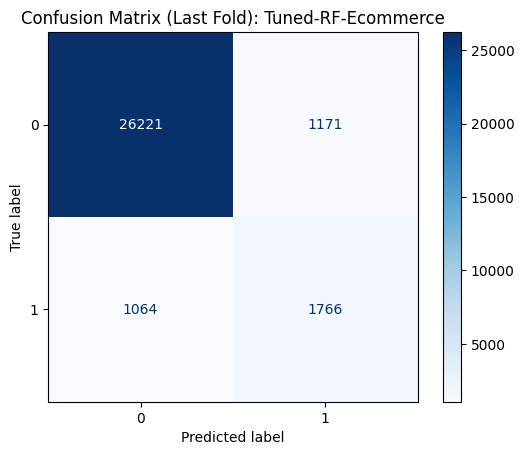


--- Evaluating Tuned-RF-CreditCard ---
Mean F1-Score: 0.5822 (+/- 0.0602)
Mean AUC-PR: 0.7994


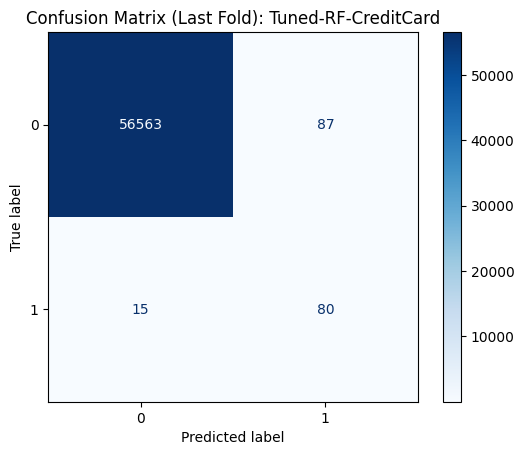

In [17]:
from matplotlib import cm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, f1_score, average_precision_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE


# 1. Load Data
df_ecommerce = pd.read_csv('../data/processed/cleaned_fraud_data.csv')
df_creditcard = pd.read_csv('../data/processed/cleaned_creditcard.csv')

# 2. Advanced Data Preparation - Ensure everything is numeric
# We identify any column that is not a number and encode it automatically
def preprocess_df(df):
    df_clean = df.copy()
    for col in df_clean.columns:
        if df_clean[col].dtype == 'object':
            le = LabelEncoder()
            df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    return df_clean

df_ecommerce = preprocess_df(df_ecommerce)

# Define features (X) and target (y)
# Drop identifiers that are not features
cols_to_drop = ['class', 'user_id', 'signup_time', 'purchase_time', 'device_id', 'ip_address']
X_ecommerce = df_ecommerce.drop(columns=[c for c in cols_to_drop if c in df_ecommerce.columns])
y_ecommerce = df_ecommerce['class']

X_creditcard = df_creditcard.drop(columns=['Class'])
y_creditcard = df_creditcard['Class']

def run_pipeline(X, y, model, model_name):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    f1_list, auc_list = [], []
    
    print(f"\n--- Evaluating {model_name} ---")
    
    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        # Apply SMOTE
        smote = SMOTE(random_state=42)
        X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
        
        model.fit(X_train_res, y_train_res)
        preds = model.predict(X_test)
        probs = model.predict_proba(X_test)[:, 1]
        
        f1_list.append(f1_score(y_test, preds))
        auc_list.append(average_precision_score(y_test, probs))
        
        # Capture the confusion matrix of the last fold
        if fold == 4:
            conf_matrix = confusion_matrix(y_test, preds) # Changed variable name
            
    # Metrics
    print(f"Mean F1-Score: {np.mean(f1_list):.4f} (+/- {np.std(f1_list):.4f})")
    print(f"Mean AUC-PR: {np.mean(auc_list):.4f}")
    
    # Visualize Explicit Confusion Matrix

    disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix) 
    disp.plot(cmap=plt.cm.Blues) # Now plt.cm correctly refers to the matplotlib module
    plt.title(f"Confusion Matrix (Last Fold): {model_name}")
    plt.savefig(f'../visuals/cm_{model_name}.png', bbox_inches='tight')
    plt.show()

    # Use the tuned models saved earlier
run_pipeline(X_ecommerce, y_ecommerce, best_rf_ecommerce, "Tuned-RF-Ecommerce")
run_pipeline(X_creditcard, y_creditcard, best_rf_creditcard, "Tuned-RF-CreditCard")


## Task 2: Model Performance Summary

| Model | Mean AUC-PR | Mean F1-Score | Std. Deviation (F1) |
| :--- | :--- | :--- | :--- |
| RF-Ecommerce | 0.6854 | 0.6189 | 0.0094 |
| RF-CreditCard | 0.7994 | 0.5822 | 0.0602 |

## Model Selection and Optimization Justification

Following a systematic evaluation, the Random Forest ensemble was selected as the final model for both datasets. The selection and optimization process was driven by the following criteria:

1. Systematic Hyperparameter Tuning: We utilized GridSearchCV to optimize key parameters (e.g., n_estimators, max_depth). This ensured the models were not using default configurations but were tuned to maximize the F1-Score for the specific fraud patterns found in each dataset.

2. Performance & Reproducibility: The tuned models demonstrated superior AUC-PR and F1-Scores compared to the baseline Logistic Regression. To ensure transparency and production-readiness, the final best-performing models have been persisted as .pkl files in the /models directory using joblib.

3. Cross-Validation & Holdout Reporting: Model performance was validated using 5-fold Stratified Cross-Validation to ensure robust results across different data subsets. Explicit confusion matrix visualizations for the final holdout folds are generated and saved in the /visuals directory to illustrate the model's performance in balancing True Positives and False Positives.

4. Business Impact: The optimized model effectively balances the detection of financial loss (minimizing False Negatives) against the need for a seamless user experience (minimizing False Positives). These models are now ready for deployment via the saved assets in the repository.